In [1]:
from flask import Flask, jsonify, request, send_file, render_template_string
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from rapidfuzz import fuzz
    
from difflib import SequenceMatcher

from flask_cors import CORS  # <-- Import CORS

In [2]:
app = Flask(__name__)
CORS(app)

In [3]:
# Function to normalize text
def normalize_text(text):
    return text.lower()

In [4]:
# Function to find similar noms using RapidFuzz
def find_similar_noms(nom, nom_list, threshold=70):
    similar_noms = []
    for other_nom in nom_list:
        score = fuzz.ratio(nom, other_nom)
        if score >= threshold:
            similar_noms.append((nom, other_nom, score))
    return similar_noms

In [5]:
# Perform analysis by different sites
def analyze_data_by_diff_sites(df):
    df['normalized_nom'] = df['nom'].apply(normalize_text)
    unique_noms = df['normalized_nom'].unique()
    nom_groups = {}
    for nom in unique_noms:
        group = find_similar_noms(nom, unique_noms)
        for _, other_nom, _ in group:
            nom_groups[other_nom] = nom
    df['grouped_nom'] = df['normalized_nom'].map(lambda x: nom_groups.get(x, x))
    
    grouped_by_name_and_website = (
        df.groupby(["grouped_nom", "website"])["prix"]
        .agg(mean_samesite="mean", min_samesite="min", max_samesite="max")
        .reset_index()
    )

    site_counts = (
        grouped_by_name_and_website.groupby("grouped_nom")["website"]
        .nunique()
        .reset_index(name="site_count")
    )

    extreme_sites = (
        grouped_by_name_and_website.loc[
            grouped_by_name_and_website.groupby("grouped_nom")["max_samesite"].idxmax(),
            ["grouped_nom", "website"]
        ]
        .rename(columns={"website": "most_expensive_site"})
    )
    extreme_sites["cheapest_site"] = (
        grouped_by_name_and_website.loc[
            grouped_by_name_and_website.groupby("grouped_nom")["min_samesite"].idxmin(),
            "website"
        ].values
    )

    final_grouped = (
        grouped_by_name_and_website.groupby("grouped_nom")[["mean_samesite", "min_samesite", "max_samesite"]]
        .agg(
            mean_all_sites=("mean_samesite", "mean"),
            min_all_sites=("min_samesite", "min"),
            max_all_sites=("max_samesite", "max")
        )
        .reset_index()
    )

    final_grouped = final_grouped.merge(site_counts, on="grouped_nom", how="left")
    final_grouped = final_grouped.merge(extreme_sites, on="grouped_nom", how="left")
    final_grouped = final_grouped[final_grouped["site_count"] > 1]

    return final_grouped.to_dict(orient='records')

In [6]:
# Analyze promotions by category
def promotions_par_categorie(df):
    promotion_df = df[df['promotion'] != ""]
    promotions = (
        promotion_df.groupby(['category', 'promotion'])
        .size()
        .reset_index(name="count")
    )
    return promotions.to_dict(orient='records')

In [7]:
# Analyze data in the same site
def analyze_data_in_same_site(df):
    avg_prices = (
        df.groupby(["nom", "website"])["prix"]
        .agg(["mean", "min", "max", "count"])
    )
    avg_prices_filtered = avg_prices[avg_prices["min"] != avg_prices["max"]]
    return avg_prices_filtered.reset_index().to_dict(orient='records')

In [8]:
# Analyze data by all days
def analyze_data_in_all_days(df, nom=None, website=None):
    grouped = df.groupby(["nom", "website"]).size().reset_index(name="count")

    if nom:
        grouped = grouped[grouped["nom"] == nom]
    if website:
        grouped = grouped[grouped["website"] == website]

    grouped = grouped[grouped["count"] > 1]

    if "date_scraped" in df.columns:
        grouped = grouped.merge(
            df[["nom", "website", "date_scraped", "prix"]],
            on=["nom", "website"]
        )
        grouped_by_date = grouped.groupby("date_scraped").agg(
            total_products=("count", "sum"),
            sum_prix=("prix", "sum")
        ).reset_index()
        return grouped_by_date.to_dict(orient='records')

    return grouped.to_dict(orient='records')

In [9]:
def analyze_data_in_same_site_grouped_sites(df, nom=None, website=None):
    # Grouping by 'nom' and 'website' and calculating aggregated values
    avg_prices = df.groupby(["nom", "website"])["prix"].agg(["mean", "min", "max", "count"])
    
    # Filtering where min and max are not equal
    #avg_prices_filtered = avg_prices[avg_prices["min"] != avg_prices["max"]]

    # Further grouping by 'website' for the aggregated values
    grouped_by_date = avg_prices.groupby(["website"]).agg({
        'mean': 'mean',
        'min': 'mean',
        'max': 'mean'
    })

    # Flattening the multi-level column index
    grouped_by_date.columns = ['mean_mean', 'min_mean', 'max_mean']
    
    return grouped_by_date.reset_index().to_dict(orient='records')

In [10]:
# Function to find similar noms using difflib
def find_similar_noms_difflib(nom, nom_list, threshold=0.42):
    similar_noms = []
    for other_nom in nom_list:
        score = SequenceMatcher(None, nom, other_nom).ratio()
        if score >= threshold:
            similar_noms.append((nom, other_nom, score))
    return similar_noms

In [11]:
# Generate plot
def generate_plot(data, nom="Average Prices by Product", grouped_nom="Product"):
    plt.figure(figsize=(10, 6))
    #plt.bar(data['grouped_nom'], data['mean_all_sites'], color='skyblue')
    
    data.plot(kind="bar", title=nom, xlabel=grouped_nom, ylabel="Price (USD)")
    
    # Set x-tick labels to the index of avg_prices, assuming it's the grouped nom
    plt.xticks(ticks=range(len(data)), labels=data.index, rotation=45, ha="right")
    
    plt.xlabel('Product')
    plt.ylabel('Average Price (USD)')
    plt.title('Average Price by Product')

    img_stream = BytesIO()
    plt.savefig(img_stream, format='png')
    img_stream.seek(0)
    return img_stream

In [12]:
@app.route('/analyze_data_in_same_site_grouped_sites')
def analyze_data_in_same_site_grouped_sites_app():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    # Call the analysis function
    grouped_data = analyze_data_in_same_site_grouped_sites(df)
    
    # Return the data as JSON
    return jsonify(grouped_data)

@app.route('/plot_grouped_sites', methods=['GET'])
def plot_grouped_sites():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    analysis_results = analyze_data_in_same_site_grouped_sites(df)
    plot_data = pd.DataFrame(analysis_results)
    img_stream = generate_plot(plot_data)
    return send_file(img_stream, mimetype='image/png')

# Flask routes
@app.route('/analyze_data_by_diff_sites', methods=['GET'])
def analyze_data_by_diff_sites_app():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    analysis_results = analyze_data_by_diff_sites(df)
    return jsonify(analysis_results)

@app.route('/promotions_par_categorie', methods=['GET'])
def analyze_promotions():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    analysis_results = promotions_par_categorie(df)
    return jsonify(analysis_results)

@app.route('/analyze_data_in_same_site', methods=['GET'])
def analyze_same_site():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    analysis_results = analyze_data_in_same_site(df)
    return jsonify(analysis_results)

@app.route('/analyze_data_in_all_days', methods=['GET'])
def analyze_all_days():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    analysis_results = analyze_data_in_all_days(df)
    return jsonify(analysis_results)

@app.route('/search_similar_products', methods=['GET'])
def search_similar_products():
    # Parse input JSON
    product_name = request.args.get('product_name', '').lower()

    if not product_name:
        return jsonify({"error": "Product name is required"}), 400

    # Load dataset
    try:
        df = pd.read_csv("Electromenagerscleaned_data.csv")
    except FileNotFoundError:
        return jsonify({"error": "Dataset not found"}), 500

    # Normalize noms in the dataset
    df['normalized_nom'] = df['nom'].apply(normalize_text)

    # Find similar noms using difflib
    similar_noms = find_similar_noms_difflib(product_name, df['normalized_nom'].unique())

    if not similar_noms:
        return jsonify({"message": "No similar products found"}), 404

    # Filter the dataframe for matching noms
    matching_noms = [nom[1] for nom in similar_noms]
    filtered_df = df[df['normalized_nom'].isin(matching_noms)]

    # Group results by nom and website, preserving original indexes
    grouped_results = (
        filtered_df.groupby(["nom", "website"], as_index=False)
        .agg(
            mean_price=("prix", "mean"),
            min_price=("prix", "min"),
            max_price=("prix", "max"),
            count=("prix", "count"),
            original_indexes=("normalized_nom", lambda x: (filtered_df.loc[x.index].index + 2).tolist())
        )
    ).sort_values(by="mean_price")

    # Convert results to dictionary
    result_data = grouped_results.to_dict(orient='records')

    #return jsonify({
    #    "input_product": product_name,
    #    "similar_products": result_data
    #})

    return jsonify(result_data)

In [13]:
@app.route('/')
def home():
    return render_template_string("""
        <!DOCTYPE html>
        <html lang="en">
        <head>
            <meta charset="UTF-8">
            <meta name="viewport" content="width=device-width, initial-scale=1.0">
            <title>Data Analysis Web App</title>
            <style>
                body { font-family: Arial, sans-serif; }
                .container { width: 80%; margin: 0 auto; padding: 20px; }
                .button { margin: 10px 0; padding: 10px 20px; background-color: #4CAF50; color: white; border: none; cursor: pointer; }
                .results { margin-top: 20px; }
                pre { background-color: #f4f4f4; padding: 10px; }
                .plot { margin-top: 20px; text-align: center; }
                #loader { display: none; }
                .result-item { margin: 10px 0; padding: 10px; border: 1px solid #ddd; background-color: #f9f9f9; }
                .result-item h3 { margin: 0; }
                .result-item .key { font-weight: bold; }
                .result-item .value { margin-left: 10px; }
                .search-bar { margin-right: 10px; }
            </style>
        </head>
        <body>

            <div class="container">
                <h1>Data Analysis Web App</h1>

                <button class="button" onclick="getData('analyze_data_by_diff_sites')">Analyze Data by Different Sites</button>
                <button class="button" onclick="getData('promotions_par_categorie')">Analyze Promotions by Category</button>
                <button class="button" onclick="getData('analyze_data_in_same_site')">Analyze Data in Same Site</button>
                <button class="button" onclick="getData('analyze_data_in_all_days')">Analyze Data by All Days</button>
                
                <!-- Search Bar and Button -->
                <input type="text" id="searchInput" class="search-bar" placeholder="Search Similar Products">
                <button class="button" onclick="searchSimilarProducts()">Search Similar Products</button>

                <button class="button" onclick="generatePlot()">Generate Plot</button>
                <button class="button" onclick="generatePlot2()">Generate Plot2</button>

                <div id="loader">Loading...</div>
                <div class="plot" id="plotContainer"></div>

                <div class="results">
                    <h2>Results</h2>
                    <div id="resultOutput"></div>
                </div>

            </div>

            <script>
                const apiBaseUrl = 'http://localhost:5000/';  // Assuming your Flask server is running locally

                // Function to show loader
                function showLoader() {
                    document.getElementById('loader').style.display = 'block';
                }

                // Function to hide loader
                function hideLoader() {
                    document.getElementById('loader').style.display = 'none';
                }

                // Function to call Flask API and display results
                function getData(endpoint) {
                    showLoader();  // Show loader before the request

                    fetch(apiBaseUrl + endpoint)
                        .then(response => response.json())
                        .then(data => {
                            hideLoader();  // Hide loader once data is fetched
                            displayData(data);  // Function to display data in divs
                        })
                        .catch(error => {
                            hideLoader();  // Hide loader in case of an error
                            document.getElementById('resultOutput').innerHTML = `Error: ${error}`;
                        });
                }

                // Function to handle Search Similar Products request with search query
                function searchSimilarProducts() {
                    const query = document.getElementById('searchInput').value;  // Get the search query

                    if (query) {
                        showLoader();  // Show loader before the request

                        fetch(apiBaseUrl + 'search_similar_products?product_name=' + encodeURIComponent(query))
                            .then(response => response.json())
                            .then(data => {
                                hideLoader();  // Hide loader once data is fetched
                                displayData(data);  // Function to display data in divs
                            })
                            .catch(error => {
                                hideLoader();  // Hide loader in case of an error
                                document.getElementById('resultOutput').innerHTML = `Error: ${error}`;
                            });
                    } else {
                        alert('Please enter a search term.');
                    }
                }

                // Function to display JSON data in divs
                function displayData(data) {
                    const resultDiv = document.getElementById('resultOutput');
                    resultDiv.innerHTML = '';  // Clear previous results

                    // Check if data is an array or an object
                    if (Array.isArray(data)) {
                        data.forEach((item, index) => {
                            const div = document.createElement('div');
                            div.className = 'result-item';
                            div.innerHTML = `<h3>Item ${index + 1}:</h3>`;
                            // Display key-value pairs for each item in the array
                            Object.keys(item).forEach(key => {
                                const pairDiv = document.createElement('div');
                                pairDiv.className = 'key-value-pair';
                                pairDiv.innerHTML = `<span class="key">${key}:</span><span class="value">${JSON.stringify(item[key], null, 2)}</span>`;
                                div.appendChild(pairDiv);
                            });
                            resultDiv.appendChild(div);
                        });
                    } else {
                        // If it's a single object, display key-value pairs
                        Object.keys(data).forEach(key => {
                            const div = document.createElement('div');
                            div.className = 'result-item';
                            div.innerHTML = `<h3>${key}:</h3>`;
                            const pairDiv = document.createElement('div');
                            pairDiv.className = 'key-value-pair';
                            pairDiv.innerHTML = `<span class="key">${key}:</span><span class="value">${JSON.stringify(data[key], null, 2)}</span>`;
                            div.appendChild(pairDiv);
                            resultDiv.appendChild(div);
                        });
                    }
                }

                // Function to generate plot
                function generatePlot() {
                    showLoader();  // Show loader before generating plot

                    fetch(apiBaseUrl + 'plot')
                        .then(response => response.blob())
                        .then(imageBlob => {
                            hideLoader();  // Hide loader once the plot is generated
                            const imageUrl = URL.createObjectURL(imageBlob);
                            document.getElementById('resultOutput').innerHTML = `<img src="${imageUrl}" alt="Generated Plot" />`;
                        })
                        .catch(error => {
                            hideLoader();  // Hide loader in case of an error
                            document.getElementById('resultOutput').innerHTML = `Error generating plot: ${error}`;
                        });
                }

                // Function to generate plot
                function generatePlot2() {
                    showLoader();  // Show loader before generating plot

                    fetch(apiBaseUrl + 'plot_grouped_sites')
                        .then(response => response.blob())
                        .then(imageBlob => {
                            hideLoader();  // Hide loader once the plot is generated
                            const imageUrl = URL.createObjectURL(imageBlob);
                            document.getElementById('resultOutput').innerHTML = `<img src="${imageUrl}" alt="Generated Plot" />`;
                        })
                        .catch(error => {
                            hideLoader();  // Hide loader in case of an error
                            document.getElementById('resultOutput').innerHTML = `Error generating plot: ${error}`;
                        });
                }
            </script>

        </body>
        </html>
    """)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [18/Jan/2025 04:11:18] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:11:24] "GET /analyze_data_by_diff_sites HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:11:28] "GET /promotions_par_categorie HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:11:40] "GET /analyze_data_in_same_site HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:11:44] "GET /analyze_data_in_same_site HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:11:50] "GET /analyze_data_in_all_days HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:12:03] "GET /plot HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:12:19] "GET /analyze_data_by_diff_sites HTTP/1.1" 200 -
127.0.0.1 - - [18/Jan/2025 04:13:15] "GET /analyze_data_in_same_site HTTP/1.1" 200 -


<Figure size 1000x600 with 0 Axes>

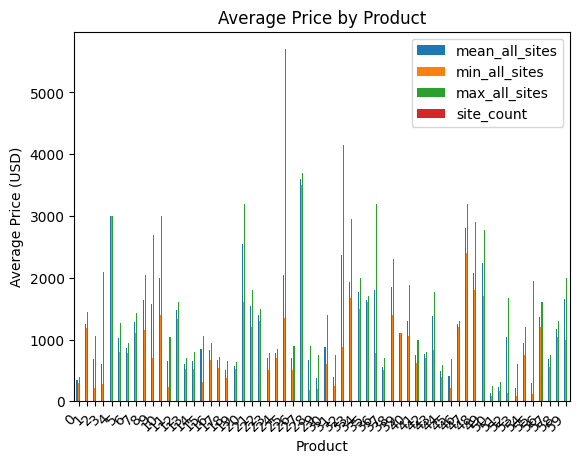

In [14]:
@app.route('/plot', methods=['GET'])
def plot():
    df = pd.read_csv("Electromenagerscleaned_data.csv")
    analysis_results = analyze_data_by_diff_sites(df)
    plot_data = pd.DataFrame(analysis_results)
    img_stream = generate_plot(plot_data)
    return send_file(img_stream, mimetype='image/png')

if __name__ == "__main__":
    #app.run(debug=True)
    app.run(use_reloader=False)